<h2></h2>
<center>
<h1><b>Fall 2026<br/>
CSC-372 Project Part 6<br/>
Neural Network Library</b></h1>


<img src="Project5.gif" width="40%" style="filter: invert(1);">

</center>

Modern deep learning frameworks such as PyTorch make it remarkably easy to define a neural network, compute a loss, call `loss.backward()`, and update the model's parameters.

But what exactly happens when we call backward()?

In this assignment, you will find out by <font color="violet">building a small automatic differentiation (autograd) engine from scratch</font>. By the end of the assignment, you will have implemented the essential machinery that allows neural networks to learn.

Your implementation will begin with a simple <font color="violet">Value object</font> representing a single scalar number. Unlike an ordinary Python number, however, a Value <font color="violet">will remember how it was computed</font>. As you perform arithmetic operations, your program <font color="violet">will construct a computational graph connecting values and operations</font>.

You will then implement the derivatives associated with these operations and use the chain rule to propagate gradients backward through the graph. This will allow you to implement your own version of:

`loss.backward()`

Once your autograd engine is working, you will use it to <font color="violet">build the basic components of a neural network—including neurons, layers, and a multilayer perceptron (MLP). Finally, you will train your network using gradient descent</font>.

The goal is not to build a fast or production-ready deep learning framework. Instead, the goal is to understand the relatively small set of ideas underneath frameworks such as PyTorch.

<br/>
<hr/>
<br/>

## **Q1**. Building the `Value` Class

We will begin by creating the fundamental building block of our autograd engine: the `Value` class.

The `Value` class will be the **principal data structure** used throughout this assignment. You can think of it as playing a role similar to:

- a `Tensor` in PyTorch, or
- a `DataFrame` in pandas.

Just as most operations in PyTorch operate on and return `Tensor` objects, the operations in our autograd engine will operate on and return `Value` objects.

There is one important simplification: while a PyTorch `Tensor` can contain scalars, vectors, matrices, or higher-dimensional arrays, our `Value` object will contain only **a single scalar number**.

However, a `Value` will store more than just that number. It will also keep track of information that allows us to reconstruct **how the value was computed**. This will eventually allow us to traverse the computation backward and calculate gradients.



### 1.1. Define the `Value` Class

Create a class called `Value`. Each `Value` object should store the following information:

- **`data`** — the scalar numerical value represented by this object.
- **`grad`** — the derivative of the final output with respect to this value. Initialize this to `0.0`.
- **`_prev`** — the `Value` objects that were used to produce this value. Store these as a `set`.
- **`_op`** — a string describing the operation that produced this value, such as `"+"` or `"*"`.
- **`label`** — an optional human-readable name that will make computational graphs easier to inspect.

Your constructor should support creating objects such as:

```python
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
```

At this point, `a` and `b` are **leaf nodes**. They contain values, but they were not produced by performing an operation on other `Value` objects.

---


In [58]:
class Value:

  def __init__(self, data, label=""):

    self.data = data
    self.grad = 0.0
    self.label = label
    self._prev = set()
    self._op = ""



In [59]:
# Test code

a = Value(2.0, label="a")

assert a.data == 2.0
assert a.grad == 0.0
assert a.label == "a"
assert a._prev == set()
assert a._op == ""

b = Value(-3.5)

assert b.data == -3.5
assert b.grad == 0.0
assert b._prev == set()
assert b._op == ""

print("1.1 complete!")

Step 1 complete!



### 1.2. Supporting Addition

Next, we want our `Value` objects to behave like numbers. In particular, we would like to write:

```python
c = a + b
```

To make the `+` operator work with `Value` objects, implement the `__add__` method.

The result of `a + b` should be a **new `Value` object** whose `data` contains:

```python
a.data + b.data
```

But storing the numerical result is only half of the job.

The new `Value` must also remember **how it was created**. This is where the `_prev` and `_op` attributes become important.

For the operation:

```python
c = a + b
```

`c` should record:

```text
c.data  → the result of a.data + b.data
c._prev → {a, b}
c._op   → "+"
```

The `_prev` attribute tells us **which `Value` objects were the inputs to this computation**, while `_op` tells us **which operation was applied to those inputs**.

Together, these attributes allow us to reconstruct the computational graph:

```text
a ──┐
    + ──> c
b ──┘
```

Notice that we do not need to explicitly create a separate graph object. **The graph is constructed automatically as `Value` objects perform operations on one another.**

For example, if we subsequently write:

```python
d = c + a
```

then `d` should remember that it was created from `c` and `a`, while `c` already remembers that it was created from `a` and `b`.

We therefore have enough information stored inside the `Value` objects themselves to reconstruct the entire chain of computation.

---


In [ ]:
#Expand your class here

class Value:
  pass




In [ ]:
a = Value(2.0, label="a")
b = Value(3.0, label="b")

c = a + b

assert isinstance(c, Value)
assert c.data == 5.0
assert c._op == "+"
assert c._prev == {a, b}

assert a.data == 2.0
assert b.data == 3.0
assert a._prev == set()
assert b._prev == set()

a = Value(1.0)
b = Value(2.0)
c = Value(4.0)

d = a + b
e = d + c

assert d.data == 3.0
assert d._prev == {a, b}

assert e.data == 7.0
assert e._prev == {d, c}

print("Step 2 passed!")


### 1.3. Supporting Multiplication

Implement the same behavior for multiplication by defining `__mul__`.

For example:

```python
d = a * b
```

should create a new `Value` whose numerical value is:

```python
a.data * b.data
```

and which records:

```text
d._prev → {a, b}
d._op   → "*"
```

Again, performing the operation should both **compute a value** and **add a new node to the computational graph**.

---

In [ ]:
# Test code

a = Value(2.0, label="a")
b = Value(-3.0, label="b")

c = a * b

assert isinstance(c, Value)
assert c.data == -6.0
assert c._op == "*"
assert c._prev == {a, b}

a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")

e = a * b
d = e + c

assert e.data == -6.0
assert e._op == "*"
assert e._prev == {a, b}

assert d.data == 4.0
assert d._op == "+"
assert d._prev == {e, c}

print("Step 3 passed!")



### 1.4. Inspecting Values

Implement `__repr__` so that printing a `Value` gives useful information.

For example:

```python
a = Value(2.0)
print(a)
```

might produce:

```text
Value(data=2.0)
```

The exact formatting is up to you, but it should make debugging your autograd engine easier.

In [ ]:
# Test
Value(data=2.0)

representation = repr(a)

assert isinstance(representation, str)
assert "2.0" in representation

print("Step 4 passed!")



### 1.5. Test Your Implementation

Once you have implemented the class, the following code should work:

```python
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")

e = a * b
d = e + c
```

Inspect the values of:

```python
e.data
e._prev
e._op

d.data
d._prev
d._op
```

From this information, you should be able to reconstruct the computation:

```text
a ──┐
    * ──> e ──┐
b ──┘         + ──> d
          c ──┘
```

At this stage, **do not implement backpropagation or calculate any derivatives**. Your goal is simply to make every computation produce a `Value` that stores its numerical result **and remembers how that result was produced**.

In [ ]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
f = Value(-2.0, label="f")

e = a * b
d = e + c
L = d * f

assert e.data == -6.0
assert d.data == 4.0
assert L.data == -8.0

assert e._prev == {a, b}
assert d._prev == {e, c}
assert L._prev == {d, f}

assert e._op == "*"
assert d._op == "+"
assert L._op == "*"

print("All Value class tests passed!")

---

# **Q2**. Teaching Operations How to Differentiate

In 1, our `Value` objects learned how to **remember the computation that produced them**. We can now build a computational graph such as:

```text
a ──┐
    * ──> e ──┐
b ──┘         + ──> d
          c ──┘
```

However, our `Value` class does not yet know how to compute gradients.

Our next goal is to teach each operation how to propagate a gradient **backward to its inputs**.

## Step 1: Add a `_backward` Function

Every `Value` should have a `_backward` function.

When a `Value` is first created, `_backward` should be a function that does nothing.

For example, a leaf node such as:

```python
a = Value(2.0)
```

was not produced by an operation, so there is nothing before `a` to propagate a gradient to.

Add a `_backward` function to your `Value` class that initially does nothing.


In [ ]:
a = Value(2.0)

assert callable(a._backward)

# Calling it should not produce an error.
a._backward()

print("Step 1 passed!")



## 2.1. Backpropagating Through Addition

Consider:

```python
a = Value(2.0)
b = Value(3.0)

c = a + b
```

Mathematically,

$$c = a + b$$

so the local derivatives are:

$$\frac{\partial c}{\partial a}=1$$

and

$$\frac{\partial c}{\partial b}=1$$

Suppose that during backpropagation we already know `c.grad`, which represents:

$$\frac{\partial L}{\partial c}$$

where $L$ is the final output or loss.

Using the chain rule:

$$
\frac{\partial L}{\partial a}
=
\frac{\partial L}{\partial c}
\frac{\partial c}{\partial a}
$$

and similarly for $b$.

Modify `__add__` so that the `Value` it creates has a `_backward` function capable of propagating `out.grad` to the inputs of the addition.

Remember that gradients should be **accumulated**, rather than overwritten.




In [ ]:
a = Value(2.0)
b = Value(3.0)

c = a + b

c.grad = 4.0  # manually / artificially setting gradient
c._backward()

assert a.grad == 4.0
assert b.grad == 4.0

print("Addition backward test passed!")


Why `4.0`?

Because:

$$
\frac{\partial L}{\partial a}
=
\underbrace{\frac{\partial L}{\partial c}}_{4}
\underbrace{\frac{\partial c}{\partial a}}_{1}
=4
$$



---

## 2.2. Backpropagating Through Multiplication

Now consider:

```python
a = Value(2.0)
b = Value(3.0)

c = a * b
```

Mathematically,

$$c=ab$$

The local derivatives are:

$$\frac{\partial c}{\partial a}=b$$

and

$$\frac{\partial c}{\partial b}=a$$

Modify `__mul__` so that its output has a `_backward` function that propagates the output gradient to both inputs.

Again, use the chain rule and remember to **accumulate** gradients.



In [ ]:
a = Value(2.0)
b = Value(3.0)

c = a * b

c.grad = 4.0
c._backward()

assert a.grad == 12.0
assert b.grad == 8.0

print("Multiplication backward test passed!")


The expected gradients are:

$$\frac{\partial L}{\partial a}=4(3)=12$$

and

$$\frac{\partial L}{\partial b}=4(2)=8$$

---



## 2.3. Why Gradients Must Accumulate

A value may influence the final output through **more than one path**.

Consider:

```python
a = Value(3.0)

b = a + a
```

Because $b=2a$,

$$\frac{\partial b}{\partial a}=2$$

Your implementation should therefore accumulate both contributions to `a.grad`.


In [ ]:
a = Value(3.0)

b = a + a

b.grad = 1.0
b._backward()

assert a.grad == 2.0

print("Gradient accumulation test passed!")



If this test fails, check whether your `_backward` functions are **adding to** gradients or replacing them.

---

At this point, individual operations know how to propagate gradients backward.

In [ ]:
a = Value(2.0)
b = Value(3.0)

c = a * b
d = c + a

# d = ab + a

d.grad = 1.0

# Manually walk backward through the graph
d._backward()
c._backward()

assert d.grad == 1.0
assert c.grad == 1.0
assert a.grad == 4.0
assert b.grad == 2.0

print("Part 2 passed!")

Here,

$$d = ab + a$$

so:

$$
\frac{\partial d}{\partial a}
=
b+1
=
4
$$

and

$$
\frac{\partial d}{\partial b}
=
a
=
2
$$

Notice something important: **we still had to decide ourselves that `d._backward()` should be called before `c._backward()`.**

Our individual operations know how to differentiate themselves, but our autograd engine does not yet know how to automatically traverse an entire computational graph.

That is the problem we will solve next.

---

# **Q3**. Implementing `backward()`

In Part 2, each operation learned how to propagate gradients to its immediate inputs.

However, we still had to manually call:

```python
d._backward()
c._backward()
```

For a neural network containing thousands or millions of operations, manually determining the correct order would obviously be impossible.

Our goal is now to implement:

```python
d.backward()
```

and have our autograd engine automatically propagate gradients through the entire computational graph.

**Why Does Order Matter?**

Consider:

```text
a ──┐
    * ──> c ──┐
b ──┘         + ──> d
          a ──┘
```

Before we can propagate the gradient from `c` to `a` and `b`, we first need to know the gradient of `c`.

Therefore, backpropagation must process nodes in an order such that a node receives all of its gradient contributions **before** its `_backward()` function is called.

We need a way to order the nodes in our computational graph.

---



## 3.1. Topological Ordering

A **topological ordering** of a computational graph places every node after the nodes that it depends on.

For example, for:

```python
a = Value(2.0)
b = Value(3.0)

c = a * b
d = c + a
```

one valid topological ordering is:

```text
a, b, c, d
```

because `c` depends on `a` and `b`, and `d` depends on `c` and `a`.

Write code that starts from the final output and recursively visits its `_prev` values to construct a topological ordering of the graph.

Be careful: a node may be reachable through multiple paths. Each `Value` should appear in the ordering **exactly once**.

In [ ]:
a = Value(2.0, label="a")
b = Value(3.0, label="b")

c = a * b
c.label = "c"

d = c + a
d.label = "d"

topo = d._topological()

# your topological ordering should contain exactly four nodes:

assert len(topo) == 4
assert set(topo) == {a, b, c, d}

assert topo.index(a) < topo.index(c)
assert topo.index(b) < topo.index(c)
assert topo.index(c) < topo.index(d)

print("Topological ordering test passed!")

---

## 3.2. Traverse the Graph Backward

The topological ordering gives us the order of the **forward dependencies**:

```text
inputs → intermediate values → output
```

Backpropagation needs to travel in the opposite direction:

```text
output → intermediate values → inputs
```

Therefore, once you have constructed your topological ordering, traverse it in **reverse order** and call each node's `_backward()` function.

Before beginning this traversal, set the gradient of the final output to:

```python
self.grad = 1.0
```

Why?

If the final output is $L$, then:

$$\frac{\partial L}{\partial L}=1$$

This provides the starting point for backpropagation.

Put all of this logic inside a new method:

```python
Value.backward()
```


You should now be able to write:

```python
a = Value(2.0)
b = Value(3.0)

c = a * b
d = c + a

d.backward()
```

without manually calling `_backward()` on any intermediate values.

Recall that:

$$d=ab+a$$

Therefore:

$$\frac{\partial d}{\partial a}=b+1$$

and

$$\frac{\partial d}{\partial b}=a$$


In [ ]:
a = Value(2.0)
b = Value(3.0)

c = a * b
d = c + a

d.backward()

assert d.grad == 1.0
assert c.grad == 1.0
assert a.grad == 4.0
assert b.grad == 2.0

print("Basic backward() test passed!")

### Test a Deeper Graph

Let's make the computational graph slightly larger:

```python
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
f = Value(-2.0)

e = a * b
d = e + c
L = d * f

L.backward()
```

The forward computation is:

```text
a ──┐
    * ──> e ──┐
b ──┘         + ──> d ──┐
          c ──┘         * ──> L
                    f ──┘
```

Here:

$$e=ab$$

$$d=e+c$$

and

$$L=df$$


In [ ]:

assert L.data == -8.0

assert L.grad == 1.0
assert d.grad == -2.0
assert f.grad == 4.0
assert e.grad == -2.0
assert c.grad == -2.0
assert a.grad == 6.0
assert b.grad == -4.0

print("Deep computational graph test passed!")

---

## Final Challenge

Test whether your implementation correctly handles a value that contributes to the output through multiple paths:

Before running the test, calculate the derivative by hand.

The computation is:

$$d=(a^2+a)a$$

which can also be written as:

$$d=a^3+a^2$$

Therefore:

$$\frac{\partial d}{\partial a}=3a^2+2a$$

At $a=3$:

$$
\frac{\partial d}{\partial a}
=
3(3^2)+2(3)
=
33
$$

In [45]:
a = Value(3.0)

b = a * a
c = b + a
d = c * a

d.backward()

assert d.data == 36.0
assert a.grad == 33.0

print("Gradient accumulation through multiple paths passed!")

Gradient accumulation through multiple paths passed!




If this test passes, your autograd engine can now:

- construct a computational graph during the forward pass,
- store local derivative rules for individual operations,
- determine the dependencies between computations,
- traverse those computations in the correct order, and
- automatically calculate gradients using reverse-mode automatic differentiation.

In other words, you have implemented your own small version of:

```python
loss.backward()
```

in PyTorch.

In [44]:

class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


# Part 4: Completing the `Value` API

Our autograd engine currently supports addition and multiplication. In principle, we could express many computations using only these operations, but building neural networks would quickly become cumbersome.

Before moving on, let's make our `Value` objects behave more like ordinary Python numbers and PyTorch tensors.

We will add support for:

- exponentiation
- negation
- subtraction
- division
- operations with ordinary Python numbers
- a nonlinear activation function

For every new operation, remember the two responsibilities of our autograd engine:

1. **Forward pass:** calculate the numerical result and record how it was produced.
2. **Backward pass:** define how the gradient should propagate to the operation's inputs.



---

## 4.1. Exponentiation

Implement `__pow__` so that a `Value` can be raised to a numerical power.

For example:

```python
a = Value(3.0)

b = a ** 2
```

should calculate:

$$b=a^2$$

The local derivative is:

$$
\frac{\partial b}{\partial a}
=
2a
$$

More generally, if:

$$b=a^n$$

then:

$$
\frac{\partial b}{\partial a}
=
na^{n-1}
$$

Your implementation only needs to support powers that are ordinary Python `int` or `float` values.


In [ ]:
a = Value(3.0)

b = a ** 2
b.backward()

assert b.data == 9.0
assert a.grad == 6.0


# Try another power:

a = Value(2.0)

b = a ** 3
b.backward()

assert b.data == 8.0
assert a.grad == 12.0

print("Exponentiation test passed!")



---

## 4.2. Negation

Next, implement unary negation:

```python
b = -a
```

Mathematically:

$$b=-a$$

You do not necessarily need to create an entirely new primitive operation for negation.

Ask yourself:

> Can $-a$ be expressed using an operation our `Value` class already supports?

Implement `__neg__` using your existing operations.


In [ ]:
a = Value(3.0)

b = -a

assert isinstance(b, Value)
assert b.data == -3.0

b.backward()

assert a.grad == -1.0

print("Negation test passed!")



---

## 4.3. Subtraction

Once negation works, implement subtraction:

```python
c = a - b
```

Again, you do not need to implement subtraction as an entirely new primitive operation.

Think about how:

$$a-b$$

can be rewritten using **addition and negation**.

In [ ]:
a = Value(5.0)
b = Value(2.0)

c = a - b

assert c.data == 3.0

c.backward()

assert a.grad == 1.0
assert b.grad == -1.0

print("Subtraction test passed!")

---

## 4.4. Division

Next, implement:

```python
c = a / b
```

Rather than treating division as a completely new operation, recall that:

$$
\frac{a}{b}
=
ab^{-1}
$$

Use the operations you have already implemented to define division.


In [ ]:
a = Value(6.0)
b = Value(2.0)

c = a / b

assert c.data == 3.0

c.backward()

assert abs(a.grad - 0.5) < 1e-10
assert abs(b.grad - (-1.5)) < 1e-10

print("Division test passed!")



---

## 4.5. Working with Python Numbers

So far, expressions involving two `Value` objects should work:

```python
a + b
a * b
```

However, we also want natural expressions such as:

```python
a + 2
2 + a

a * 3
3 * a

a - 1
2 - a

a / 2
```

These are particularly important when implementing neural networks because constants appear frequently in mathematical expressions.

Modify your arithmetic methods so that ordinary Python numbers are automatically converted into `Value` objects when necessary.

You may also need to implement Python's corresponding **reverse operators**, such as:

```python
__radd__
__rmul__
__rsub__
__rtruediv__
```

In [ ]:
a = Value(4.0)

assert (a + 2).data == 6.0
assert (2 + a).data == 6.0

assert (a * 3).data == 12.0
assert (3 * a).data == 12.0

assert (a - 1).data == 3.0
assert (10 - a).data == 6.0

assert (a / 2).data == 2.0
assert (8 / a).data == 2.0

print("Python number interoperability tests passed!")


---

## 4.6. Add a Nonlinear Activation Function

A neural network consisting entirely of linear operations is still just a linear model, regardless of how many layers we stack together.

To build more expressive neural networks, we need **nonlinear activation functions**.

Implement the hyperbolic tangent activation function:

```python
a.tanh()
```

The forward computation is:

$$
t = \tanh(a)
$$

You may calculate the forward value using Python's `math.tanh`.

The derivative of $\tanh$ is:

$$
\frac{dt}{da}
=
1-t^2
$$

Notice that once you have computed the output $t$, the local derivative can be calculated directly from that output.


In [ ]:
a = Value(0.5)

t = a.tanh()

assert abs(t.data - 0.4621171573) < 1e-6

t.backward()

expected_grad = 1 - t.data**2

assert abs(a.grad - expected_grad) < 1e-6

print("tanh test passed!")

# Also verify an especially simple case:

a = Value(0.0)

t = a.tanh()
t.backward()

assert t.data == 0.0
assert a.grad == 1.0

print("tanh zero test passed!")


---

# Final Checkpoint

Your `Value` class should now support relatively natural mathematical expressions.

Try:

```python
a = Value(2.0)
b = Value(3.0)

c = ((a * b + 2) / 4) ** 2

c.backward()
```

Verify the forward calculation:

$$
c
=
\left(\frac{ab+2}{4}\right)^2
$$

For $a=2$ and $b=3$:

$$
c
=
\left(\frac{8}{4}\right)^2
=
4
$$

### Checkpoint

```python
assert c.data == 4.0

assert abs(a.grad - 3.0) < 1e-10
assert abs(b.grad - 2.0) < 1e-10

print("All Value API tests passed!")
```

Your `Value` class now behaves much more like the numerical objects provided by a deep learning framework.

You are ready to use it to build neural networks.

# **2. Trace Graph**

Uses graphviz to render the computation graph of any `Value`:

`draw_dot()` traces `_prev` links and draws each node as a box showing `data` and `grad`, with operator nodes in between.

Great for seeing the forward/backward graph on a tiny expression or a single 2-input neuron.

In [27]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

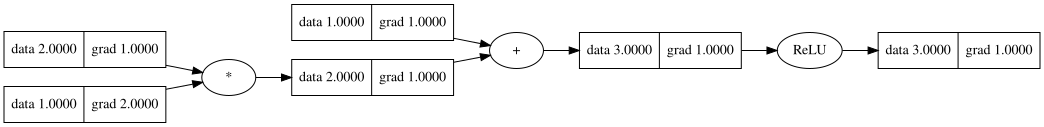

In [28]:
# a very simple example
x = Value(1.0)
y = (x * 2 + 1).relu()
y.backward()
draw_dot(y)

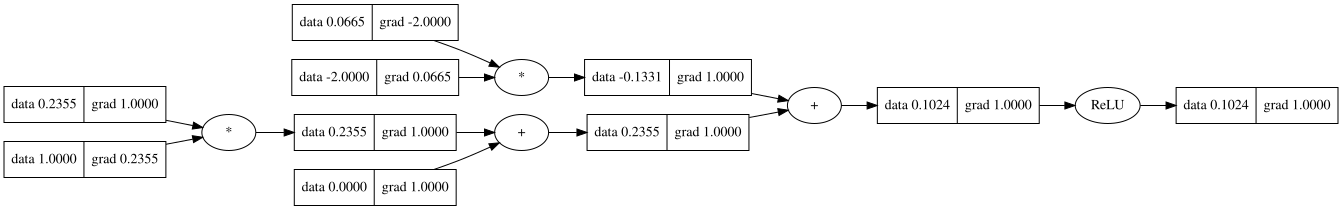

In [29]:
# a simple 2D neuron
import random
# from micrograd import nn

random.seed(1337)
# n = nn.Neuron(2)
n = Neuron(2)
x = [Value(1.0), Value(-2.0)]
y = n(x)
y.backward()

dot = draw_dot(y)
dot

# **Q4**: Building a Neural Network Library

We now have the most important piece of our deep learning framework: an **automatic differentiation engine**.

Our `Value` class can construct computational graphs and automatically calculate gradients using:

```python
loss.backward()
```

But calculating gradients is only part of building a neural network. We also need a convenient way to organize the many parameters and computations that make up a model.

In this part, you will build a small neural network library on top of your autograd engine.

Just as our `Value` class is a simplified counterpart of PyTorch's `Tensor`, the classes we build in this section will be simplified counterparts of classes in PyTorch's `torch.nn` library.

By the end, you should be able to construct a multilayer perceptron using:

```python
model = MLP(3, [4, 4, 1])
```

and retrieve all of its trainable parameters using:

```python
model.parameters()
```



---

## 4.1. The `Module` Class

In PyTorch, neural network components inherit from `nn.Module`.

We will follow a similar design.

Create a base class called:

```python
class Module:
    ...
```

For now, `Module` needs to provide two important pieces of functionality.

### `parameters()`

Implement a `parameters()` method that returns a list containing all trainable `Value` objects belonging to the module.

The base `Module` itself has no parameters, so its implementation can simply return an empty list.

### `zero_grad()`

Recall that our autograd engine **accumulates** gradients. Before performing a new backward pass during training, we therefore need to reset the gradients of all model parameters.

Implement:

```python
zero_grad()
```

which should iterate through `self.parameters()` and set the gradient of every parameter to `0.0`.


In [ ]:
m = Module()

assert m.parameters() == []

m.zero_grad()  # should run without error

print("Module test passed!")


---

## 4.2. Build a `Neuron`

A neuron is the fundamental computational unit of a neural network.

Suppose a neuron receives $n$ input features:

$$x_1,x_2,\ldots,x_n$$

The neuron has one weight corresponding to each input:

$$w_1,w_2,\ldots,w_n$$

and a bias:

$$b$$

It first computes:

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

or equivalently:

$$
z = w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$

The values $w_i$ and $b$ are the **trainable parameters** of the neuron.

Create a class called:

```python
class Neuron(Module):
    ...
```

### Constructor

The constructor should accept:

```python
Neuron(nin)
```

where `nin` represents the **number of inputs** to the neuron.

For example:

```python
n = Neuron(3)
```

should create a neuron containing:

- 3 weights
- 1 bias

Each weight and bias must be a `Value` object so that our autograd engine can calculate gradients with respect to them.

Initialize the weights to small random values. The bias may initially be set to zero.

Store the weights in a list called `w` and the bias in `b`.


In [ ]:
n = Neuron(3)

assert len(n.w) == 3
assert all(isinstance(w, Value) for w in n.w)
assert isinstance(n.b, Value)

print("Neuron initialization test passed!")


---

## 4.3. Implement the Neuron's Forward Pass

Next, make a `Neuron` callable by implementing:

```python
__call__()
```

The method should accept a list of inputs:

```python
x = [x1, x2, ..., xn]
```

and calculate:

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

Because the weights, bias, and intermediate computations are `Value` objects, performing this calculation should automatically construct a computational graph.

For now, return $z$ directly. We will add nonlinear activation functions separately.

For example:

```python
n = Neuron(3)

x = [
    Value(2.0),
    Value(-1.0),
    Value(3.0)
]

out = n(x)
```

should produce a single `Value`.


In [ ]:
n = Neuron(3)

n.w = [
    Value(1.0),
    Value(2.0),
    Value(-1.0)
]

n.b = Value(3.0)

x = [
    Value(2.0),
    Value(-1.0),
    Value(4.0)
]

out = n(x)

assert isinstance(out, Value)
assert out.data == -1.0

print("Neuron forward pass test passed!")

The expected calculation is:

$$
z=(1)(2)+(2)(-1)+(-1)(4)+3=-1
$$



---

## 4.4. Return the Neuron's Parameters

Implement the `parameters()` method for `Neuron`.

A neuron's trainable parameters consist of all of its weights and its bias:

$$
w_1,w_2,\ldots,w_n,b
$$

Therefore, a neuron with `nin` inputs should have:

$$nin+1$$

trainable parameters.


In [ ]:
n = Neuron(3)

params = n.parameters()

assert len(params) == 4
assert all(isinstance(p, Value) for p in params)

print("Neuron parameters test passed!")

# You should now also be able to use the
# `zero_grad()` method inherited from `Module`:

for p in n.parameters():
    p.grad = 5.0

n.zero_grad()

assert all(p.grad == 0.0 for p in n.parameters())

print("Neuron zero_grad test passed!")


---

## 4.5. Build a `Layer`

A neural network layer consists of **multiple neurons receiving the same inputs**.

Create:

```python
class Layer(Module):
    ...
```

The constructor should accept:

```python
Layer(nin, nout)
```

where:

- `nin` = number of inputs to each neuron
- `nout` = number of neurons in the layer

For example:

```python
layer = Layer(3, 4)
```

represents:

```text
3 inputs  →  4 neurons  →  4 outputs
```

Create `nout` separate `Neuron` objects and store them in a list.


In [ ]:
layer = Layer(3, 4)

assert len(layer.neurons) == 4
assert all(isinstance(n, Neuron) for n in layer.neurons)

for neuron in layer.neurons:
    assert len(neuron.w) == 3

print("Layer initialization test passed!")



---

## 4.6. Implement the Layer's Forward Pass

Implement `Layer.__call__()`.

Every neuron in the layer should receive the **same input vector**.

If:

```python
x = [x1, x2, x3]
```

then conceptually:

```text
                 ┌── Neuron 1 ──> output 1
                 │
[x1, x2, x3] ────├── Neuron 2 ──> output 2
                 │
                 ├── Neuron 3 ──> output 3
                 │
                 └── Neuron 4 ──> output 4
```

The layer should return the outputs produced by its neurons.

Therefore, a layer containing `nout` neurons should normally produce `nout` outputs.


In [ ]:
layer = Layer(3, 4)

x = [
    Value(1.0),
    Value(2.0),
    Value(3.0)
]

out = layer(x)

assert len(out) == 4
assert all(isinstance(v, Value) for v in out)

print("Layer forward pass test passed!")



---

## 4.7. Return All Parameters of a Layer

A layer's parameters consist of the parameters belonging to **all of its neurons**.

Implement:

```python
Layer.parameters()
```

so that it returns a single list containing every trainable parameter in the layer.

How many parameters should a `Layer(3, 4)` contain?

Each neuron has:

$$3+1=4$$

parameters.

There are 4 neurons, so:

$$4(4)=16$$

total trainable parameters.


In [ ]:
layer = Layer(3, 4)

params = layer.parameters()

assert len(params) == 16
assert all(isinstance(p, Value) for p in params)

print("Layer parameters test passed!")


---

## 4.8. Build a Multilayer Perceptron

We can now combine multiple layers to create a **Multilayer Perceptron (MLP)**.

Create:

```python
class MLP(Module):
    ...
```

The constructor should accept:

```python
MLP(nin, nouts)
```

where:

- `nin` is the number of input features
- `nouts` is a list describing the number of neurons in each layer

For example:

```python
model = MLP(3, [4, 4, 1])
```

represents the architecture:

```text
Input        Layer 1       Layer 2       Layer 3

  3    ───>    4    ───>     4    ───>    1
```

In other words:

```text
3 input features
      ↓
4 neurons
      ↓
4 neurons
      ↓
1 neuron
```

Construct the appropriate `Layer` objects and store them inside the MLP.

Be careful about the dimensions. The output size of one layer becomes the input size of the next layer.


In [ ]:
model = MLP(3, [4, 4, 1])

assert len(model.layers) == 3

assert len(model.layers[0].neurons) == 4
assert len(model.layers[1].neurons) == 4
assert len(model.layers[2].neurons) == 1

assert len(model.layers[0].neurons[0].w) == 3
assert len(model.layers[1].neurons[0].w) == 4
assert len(model.layers[2].neurons[0].w) == 4

print("MLP architecture test passed!")


---

## 4.9. Implement the MLP Forward Pass

Implement `MLP.__call__()`.

The input should first be passed through the first layer. The output of that layer should then become the input to the second layer, and so on.

Conceptually:

```text
x → Layer 1 → Layer 2 → ... → Layer N → output
```

For:

```python
model = MLP(3, [4, 4, 1])
```

the shapes should progress as:

```text
3 → 4 → 4 → 1
```

In [ ]:
model = MLP(3, [4, 4, 1])

x = [
    Value(2.0),
    Value(3.0),
    Value(-1.0)
]

out = model(x)

assert isinstance(out, Value)

print("MLP forward pass test passed!")


---

## 4.10. Return All Parameters of the MLP

Finally, implement:

```python
MLP.parameters()
```

It should return all parameters from all layers as a single list.

For:

```python
model = MLP(3, [4, 4, 1])
```

we can calculate the expected number of parameters.

The first layer has:

$$4(3+1)=16$$

The second layer has:

$$4(4+1)=20$$

The final layer has:

$$1(4+1)=5$$

Therefore, the entire network has:

$$16+20+5=41$$

trainable parameters.

In [ ]:
model = MLP(3, [4, 4, 1])

params = model.parameters()

assert len(params) == 41
assert all(isinstance(p, Value) for p in params)

print("MLP parameters test passed!")



---

## 4.11. Final Checkpoint: Connect the Neural Network to Autograd

The neural network library you just created should work directly with the autograd engine from Parts 1–3.


In [ ]:
model = MLP(3, [4, 4, 1])

x = [
    Value(2.0),
    Value(3.0),
    Value(-1.0)
]

prediction = model(x)

target = Value(1.0)

loss = (prediction - target) ** 2

model.zero_grad()
loss.backward()

# After calling `backward()`, every parameter in the
# network should have a gradient.

assert len(model.parameters()) == 41

for p in model.parameters():
    assert isinstance(p.grad, (int, float))

print("Neural network + autograd test passed!")



At this point, you have built the essential pieces of a small deep learning framework:

```text
Value
  ↓
Automatic Differentiation
  ↓
Module
  ↓
Neuron
  ↓
Layer
  ↓
MLP
```

Your `Value` objects play the role of PyTorch tensors, while `Module`, `Neuron`, `Layer`, and `MLP` provide abstractions for organizing those values into trainable neural networks.

There is now only one major piece missing: **training the network**.

We have parameters, predictions, a loss, and gradients. Next, we need to use those gradients to update the parameters and make the loss smaller.

# Part 5: Training the Neural Network

We now have all the major components of a small deep learning framework.

Our `Value` class provides automatic differentiation, and our neural network library allows us to construct models containing trainable parameters.

Now we will put everything together and actually **train a neural network**.

The basic training process should look familiar from PyTorch:

```text
Forward Pass
     ↓
Compute Loss
     ↓
Zero Gradients
     ↓
Backward Pass
     ↓
Update Parameters
     ↓
Repeat
```

The remarkable thing is that this time **you implemented every major component yourself**.

---

## Step 1: Create a Dataset

We will begin with a small binary classification dataset.

Each example contains three input features:

```python
xs = [
    [2.0,  3.0, -1.0],
    [3.0, -1.0,  0.5],
    [0.5,  1.0,  1.0],
    [1.0,  1.0, -1.0],
]
```

with corresponding target values:

```python
ys = [1.0, -1.0, -1.0, 1.0]
```

Because our final neuron uses `tanh`, its predictions will fall between approximately $-1$ and $1$, making these convenient target values.

---

## Step 2: Create the Model

Create an MLP with:

- 3 input features
- two hidden layers containing 4 neurons each
- 1 output neuron

```python
model = MLP(3, [4, 4, 1])
```


In [ ]:
assert len(model.layers) == 3
assert len(model.parameters()) == 41

print("Model created successfully!")
print("Number of parameters:", len(model.parameters()))



Before training, try running one example through the network:

```python
prediction = model(xs[0])

print("Prediction:", prediction)
print("Target:", ys[0])
```

At this point, the prediction will essentially be random because the model's parameters were randomly initialized.

---

## Step 3: Forward Pass

Run every training example through the model:

```python
ypred = [model(x) for x in xs]
```

You should receive one prediction for each training example.

### Checkpoint

```python
assert len(ypred) == len(xs)
assert all(isinstance(y, Value) for y in ypred)

print("Forward pass test passed!")
```

---

## Step 4: Calculate the Loss

We need a way to measure how different the model's predictions are from the desired targets.

For this assignment, use **mean squared error**.

For one prediction:

$$
L_i=(\hat{y}_i-y_i)^2
$$

For the entire dataset:

$$
L
=
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
$$

Use your `Value` operations to calculate this loss.

For example, you might first calculate the individual losses:

```python
losses = [(yout - ygt) ** 2
          for ygt, yout in zip(ys, ypred)]
```

and then combine them into the final loss.

### Checkpoint

```python
assert isinstance(loss, Value)
assert loss.data >= 0

print("Initial loss:", loss.data)
```

Remember this value. If training is working correctly, the loss should become smaller.

---

## Step 5: Zero the Gradients

Before calculating new gradients, reset the gradients of all model parameters:

```python
model.zero_grad()
```

### Why is this necessary?

Recall that our autograd engine uses:

```python
+=
```

when propagating gradients.

This is intentional because the same parameter may influence the loss through many different paths.

However, it also means gradients from a previous training iteration would remain unless we explicitly reset them.

This is analogous to calling:

```python
optimizer.zero_grad()
```

in PyTorch.

---

## Step 6: Backward Pass

Now calculate the gradient of the loss with respect to every parameter in the network:

```python
loss.backward()
```

Because the entire forward pass was performed using `Value` objects, the loss is connected through the computational graph to every weight and bias that contributed to the predictions.

### Checkpoint

Inspect a few parameters:

```python
for p in model.parameters()[:5]:
    print("value:", p.data, "gradient:", p.grad)
```

You should see gradients that are generally nonzero.

At this point, each parameter knows:

$$
\frac{\partial L}{\partial p}
$$

which tells us how changing that parameter would affect the loss.

---

## Step 7: Update the Parameters

Now perform one step of gradient descent.

For each parameter $p$:

$$
p
\leftarrow
p-\alpha\frac{\partial L}{\partial p}
$$

where $\alpha$ is the **learning rate**.

Choose a learning rate such as:

```python
learning_rate = 0.05
```

Then update every parameter using its gradient.

```python
for p in model.parameters():
    # Update p.data using p.grad
    ...
```

Do not create new `Value` objects during the update. Modify the numerical `data` stored by each existing parameter.

### Checkpoint

Verify that at least one parameter changes:

```python
before = [p.data for p in model.parameters()]

for p in model.parameters():
    p.data += -learning_rate * p.grad

after = [p.data for p in model.parameters()]

assert before != after

print("Parameter update test passed!")
```

---

# Step 8: Build the Training Loop

You have now completed **one iteration of gradient descent**.

Training simply means repeating this process many times:

```text
1. Forward pass
2. Calculate loss
3. Zero gradients
4. Backward pass
5. Update parameters
6. Repeat
```

Combine these steps into a training loop.

For example:

```python
for epoch in range(...):

    # 1. Forward pass
    ...

    # 2. Calculate loss
    ...

    # 3. Zero gradients
    ...

    # 4. Backward pass
    ...

    # 5. Update parameters
    ...

    # 6. Display progress
    ...
```

Print the loss periodically so you can observe whether the model is learning.

You should see something resembling:

```text
Epoch   0 | Loss:  ...
Epoch  10 | Loss:  ...
Epoch  20 | Loss:  ...
...
```

If your implementation is correct, the loss should generally **decrease during training**.

---

## Step 9: Evaluate the Trained Model

After training, calculate the model's predictions again:

```python
ypred = [model(x) for x in xs]
```

Display each prediction alongside its target.

For example:

```text
Prediction       Target
-----------------------
    ...            1
    ...           -1
    ...           -1
    ...            1
```

Since this is a binary classification problem, use the sign of the prediction to determine the predicted class:

$$
\hat{c}
=
\begin{cases}
1 & \hat{y} > 0 \\
-1 & \hat{y} < 0
\end{cases}
$$

### Checkpoint

```python
for x, y in zip(xs, ys):
    prediction = model(x)

    predicted_class = 1 if prediction.data > 0 else -1

    print(
        "prediction:",
        round(prediction.data, 3),
        "class:",
        predicted_class,
        "target:",
        y
    )
```

Your trained model should correctly classify most or all of the four training examples.

---

# Final Reflection

You have now built and trained a neural network **without using PyTorch's autograd or neural network libraries**.

Compare the system you created with the PyTorch workflow:

| Your Micrograd | PyTorch |
|---|---|
| `Value` | `Tensor` |
| `Value.backward()` | `Tensor.backward()` |
| `Module` | `nn.Module` |
| `Neuron` / `Layer` / `MLP` | `nn` layers and models |
| `model.parameters()` | `model.parameters()` |
| `model.zero_grad()` | `optimizer.zero_grad()` |
| Manual parameter update | `optimizer.step()` |

Despite the enormous difference in scale and performance, the fundamental training process is the same:

$$
\text{data}
\rightarrow
\text{model}
\rightarrow
\text{predictions}
\rightarrow
\text{loss}
\rightarrow
\text{backpropagation}
\rightarrow
\text{gradients}
\rightarrow
\text{parameter updates}
$$

The `loss.backward()` call that may have seemed like magic at the beginning of this course should now be much less mysterious.

You built it.

# **3. NN library**

## 3.1. Module

A base class giving `zero_grad()` and a `parameters()` stub.

In [30]:
class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

## 3.2. Neuron

Neuron holds weights `w` (random) and bias `b`, computes `sum(wi*xi) + b`, then optionally applies `relu()`.

In [31]:
class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"


## 3.3. Layer

A list of Neurons run on the same input.

In [32]:
class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"


MLP — stacks Layers; the last layer is linear (nonlin=False) since it produces raw scores, not activations.

In [33]:
class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"


# **4. Training Loop Demo**

In [34]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [35]:
np.random.seed(1337)
random.seed(1337)

## 4.1. Generates a 2D "moons" toy dataset (sklearn.datasets.make_moons), labels as ±1.


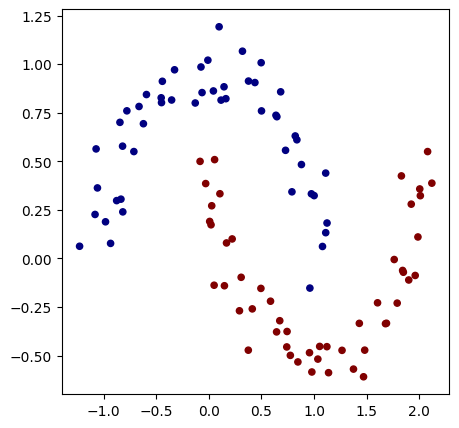

In [49]:

# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet');



## 4.2. Builds MLP(2, [16, 16, 1]) — 2 inputs → two hidden layers of 16 → 1 output.

In [37]:
# initialize a model
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [38]:
layer1 = model.layers[0]
neuron1 = layer1.neurons[0]

In [39]:
neuron1.w

[Value(data=0.23550571390294128, grad=0),
 Value(data=0.06653114721000164, grad=0)]

In [40]:
len(inputs)

315



## 4.3. Defines an SVM "max-margin" hinge loss ((1 - y*score).relu()) plus L2 regularization over all parameters.

In [41]:
# loss function
def loss(batch_size=None):

    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]

    # forward the model to get scores
    scores = list(map(model, inputs))

    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss

    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=0.8958441028683222, grad=0) 0.5


## 4.5. Trains with plain SGD for 100 steps, using a manually decaying learning rate, printing loss/accuracy each step.

In [42]:
# optimization
for k in range(100):

    # forward
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")


step 0 loss 0.8958441028683222, accuracy 50.0%
step 1 loss 1.723590533697202, accuracy 81.0%
step 2 loss 0.7429006313851133, accuracy 77.0%
step 3 loss 0.7705641260584201, accuracy 82.0%
step 4 loss 0.3692793385976538, accuracy 84.0%
step 5 loss 0.31354548191852205, accuracy 86.0%
step 6 loss 0.2814234349772434, accuracy 89.0%
step 7 loss 0.26888733313983904, accuracy 91.0%
step 8 loss 0.2567147286057417, accuracy 91.0%
step 9 loss 0.27048625516379227, accuracy 91.0%
step 10 loss 0.24507023853658041, accuracy 91.0%
step 11 loss 0.25099055297915035, accuracy 92.0%
step 12 loss 0.21560951851922952, accuracy 91.0%
step 13 loss 0.23090378446402726, accuracy 93.0%
step 14 loss 0.2015215122789945, accuracy 92.0%
step 15 loss 0.2257450627928222, accuracy 93.0%
step 16 loss 0.19447987596204114, accuracy 92.0%
step 17 loss 0.21089496199246363, accuracy 93.0%
step 18 loss 0.15983077356303604, accuracy 94.0%
step 19 loss 0.18453748746883916, accuracy 93.0%
step 20 loss 0.1897752285608764, accurac





## 4.6. Plots the resulting decision boundary over a mesh grid (this is moon_mlp.png referenced in the README).

(-1.548639298268643, 1.951360701731357)

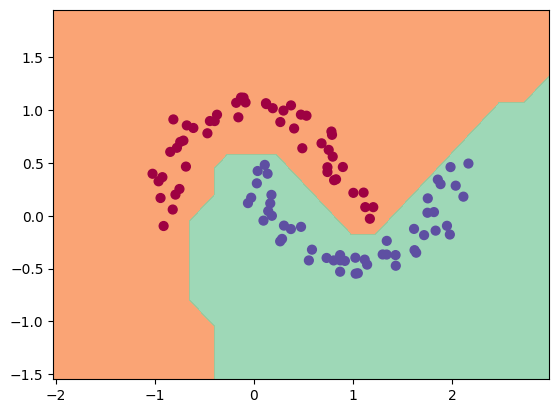

In [43]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
